In [3]:
%pip install numpy scipy networkx matplotlib scikit-fuzzy

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [4]:
# Instale a biblioteca se necessário:
# !pip install scikit-fuzzy

import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl
import matplotlib.pyplot as plt

In [5]:
# --- 1. Definir Variáveis Nebulosas ---
# Variável de Entrada: Temperatura (10°C a 30°C)
temperatura = ctrl.Antecedent(np.arange(10, 31, 1), 'temperatura')

temperatura.universe

array([10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26,
       27, 28, 29, 30])

In [6]:
# Variável de Saída: Potência do Ar-Condicionado (0% a 100%)
potencia = ctrl.Consequent(np.arange(0, 101, 1), 'potencia')

potencia.universe

array([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,
        13,  14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,
        26,  27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,
        39,  40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,
        52,  53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,
        65,  66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,
        78,  79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,
        91,  92,  93,  94,  95,  96,  97,  98,  99, 100])

C:\Users\2401557\AppData\Roaming\Python\Python313\site-packages\skfuzzy\control\fuzzyvariable.py:125: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


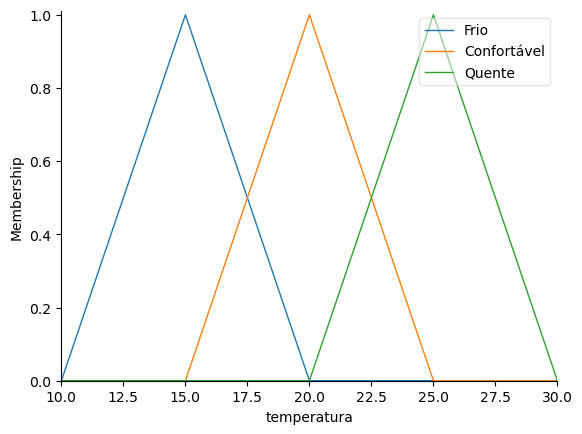

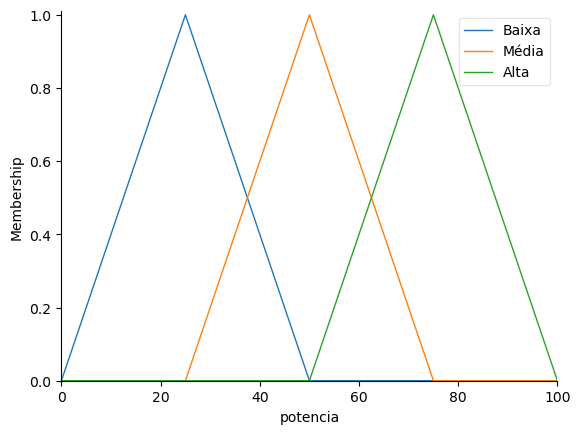

In [7]:
# --- 2. Funções de Pertinência ---
# Automáticas (triangulares)
temperatura['Frio'] = fuzz.trimf(temperatura.universe, [10, 15, 20])
temperatura['Confortável'] = fuzz.trimf(temperatura.universe, [15, 20, 25])
temperatura['Quente'] = fuzz.trimf(temperatura.universe, [20, 25, 30])

potencia['Baixa'] = fuzz.trimf(potencia.universe, [0, 25, 50])
potencia['Média'] = fuzz.trimf(potencia.universe, [25, 50, 75])
potencia['Alta'] = fuzz.trimf(potencia.universe, [50, 75, 100])

# Visualizar as funções
temperatura.view()
potencia.view()
plt.show()

In [8]:
# --- 3. Regras Nebulosas ---
regra1 = ctrl.Rule(temperatura['Frio'], potencia['Baixa'])
regra2 = ctrl.Rule(temperatura['Confortável'], potencia['Média'])
regra3 = ctrl.Rule(temperatura['Quente'], potencia['Alta'])

In [9]:
# --- 4. Sistema de Controle ---
sistema_controle = ctrl.ControlSystem([regra1, regra2, regra3])
simulador = ctrl.ControlSystemSimulation(sistema_controle)

In [10]:
# --- 5. Simular com uma Temperatura Específica ---
temperatura_input = 24  # Exemplo: 24°C
simulador.input['temperatura'] = temperatura_input
simulador.compute()  # Executa a inferência nebulosa

Para 24°C, Potência = 69.0%


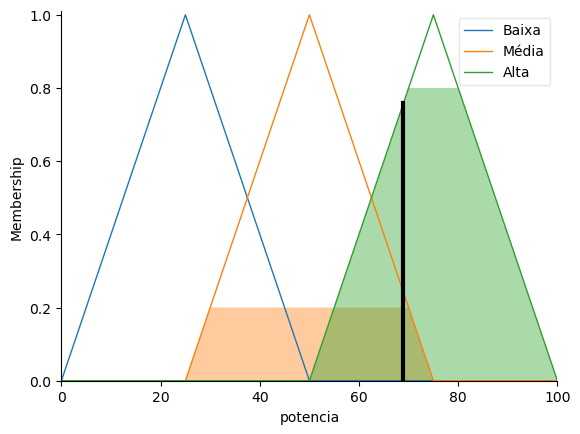

In [11]:
# --- 6. Resultado ---
print(f"Para {temperatura_input}°C, Potência = {simulador.output['potencia']:.1f}%")

# Visualizar a contribuição de cada regra
potencia.view(sim=simulador)
plt.show()

In [12]:
temperatura_input = 18  # Altere para testar
simulador.input['temperatura'] = temperatura_input
simulador.compute()
print(f"Potência para {temperatura_input}°C: {simulador.output['potencia']:.1f}%")

Potência para 18°C: 39.5%


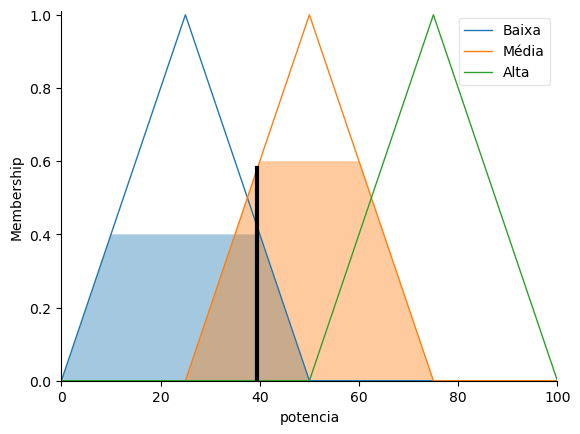

In [13]:
# Visualizar a contribuição de cada regra
potencia.view(sim=simulador)
plt.show()

# Modificando o exemplo para considerar varias entradas

In [14]:
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl
import matplotlib.pyplot as plt

# --- 1. Variáveis Nebulosas ---
temperatura = ctrl.Antecedent(np.arange(0, 41, 1), 'temperatura')
umidade = ctrl.Antecedent(np.arange(0, 101, 1), 'umidade')

ventilacao = ctrl.Consequent(np.arange(0, 101, 1), 'ventilacao')
aquecedor = ctrl.Consequent(np.arange(0, 101, 1), 'aquecedor')
irrigacao = ctrl.Consequent(np.arange(0, 101, 1), 'irrigacao')

In [15]:
# --- 2. Funções de Pertinência ---
# Temperatura
temperatura['Muito_Frio'] = fuzz.trapmf(temperatura.universe, [0, 0, 10, 15])
temperatura['Frio'] = fuzz.trimf(temperatura.universe, [10, 15, 20])
temperatura['Ideal'] = fuzz.trimf(temperatura.universe, [18, 22, 26])
temperatura['Quente'] = fuzz.trimf(temperatura.universe, [22, 27, 32])
temperatura['Muito_Quente'] = fuzz.trapmf(temperatura.universe, [28, 32, 40, 40])

# Umidade
umidade['Seco'] = fuzz.trapmf(umidade.universe, [0, 0, 30, 50])
umidade['Ideal'] = fuzz.trimf(umidade.universe, [40, 60, 80])
umidade['Umido'] = fuzz.trapmf(umidade.universe, [60, 80, 100, 100])

In [16]:
# Saídas
ventilacao['Minima'] = fuzz.gaussmf(ventilacao.universe, 0, 15)
ventilacao['Moderada'] = fuzz.gaussmf(ventilacao.universe, 50, 20)
ventilacao['Maxima'] = fuzz.gaussmf(ventilacao.universe, 100, 15)

aquecedor['Desligado'] = fuzz.gaussmf(aquecedor.universe, 0, 15)
aquecedor['Medio'] = fuzz.gaussmf(aquecedor.universe, 50, 20)
aquecedor['Maximo'] = fuzz.gaussmf(aquecedor.universe, 100, 15)

irrigacao['Nenhuma'] = fuzz.gaussmf(irrigacao.universe, 0, 15)
irrigacao['Leve'] = fuzz.gaussmf(irrigacao.universe, 30, 10)
irrigacao['Moderada'] = fuzz.gaussmf(irrigacao.universe, 60, 15)
irrigacao['Intensa'] = fuzz.gaussmf(irrigacao.universe, 100, 20)

In [17]:
# --- 3. Regras ---
rules = [
    ctrl.Rule(temperatura['Muito_Frio'] & umidade['Seco'], [
        aquecedor['Maximo'],
        ventilacao['Minima'],
        irrigacao['Leve']
    ]),
    ctrl.Rule(temperatura['Ideal'] & umidade['Ideal'], [
        aquecedor['Desligado'],
        ventilacao['Moderada'],
        irrigacao['Moderada']
    ]),
    ctrl.Rule(temperatura['Muito_Quente'] | umidade['Umido'], [
        aquecedor['Desligado'],
        ventilacao['Maxima'],
        irrigacao['Nenhuma']
    ]),
    ctrl.Rule(temperatura['Frio'] & umidade['Ideal'], [
        aquecedor['Medio'],
        ventilacao['Minima'],
        irrigacao['Leve']
    ]),
    ctrl.Rule(temperatura['Quente'] & umidade['Seco'], [
        aquecedor['Desligado'],
        ventilacao['Moderada'],
        irrigacao['Intensa']
    ])
]

In [18]:
# --- 4. Sistema de Controle ---
sistema_estufa = ctrl.ControlSystem(rules)
simulador = ctrl.ControlSystemSimulation(sistema_estufa)

In [19]:
# --- 5. Simulação ---
# Definindo inputs corretamente
temperatura_imput = 19
umidade_imput = 65
simulador.input['temperatura'] = temperatura_imput
simulador.input['umidade'] = umidade_imput

simulador.compute()

In [20]:
print(f"""
Controle da Estufa:
- Temperatura: {temperatura_imput}°C
- Umidade: {umidade_imput}%
- Aquecedor: {simulador.output['aquecedor']:.1f}%
- Ventilação: {simulador.output['ventilacao']:.1f}%
- Irrigação: {simulador.output['irrigacao']:.1f}%
""")


Controle da Estufa:
- Temperatura: 19°C
- Umidade: 65%
- Aquecedor: 44.7%
- Ventilação: 51.3%
- Irrigação: 46.2%



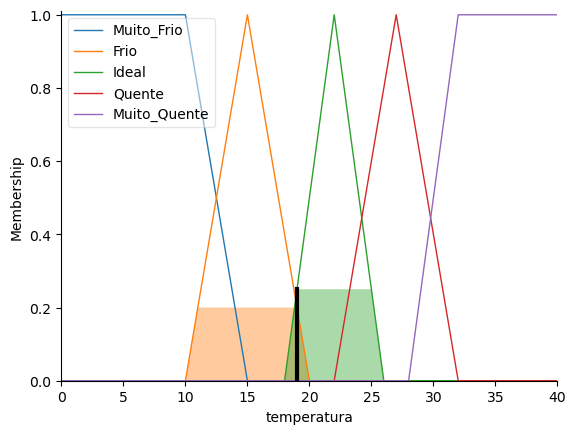

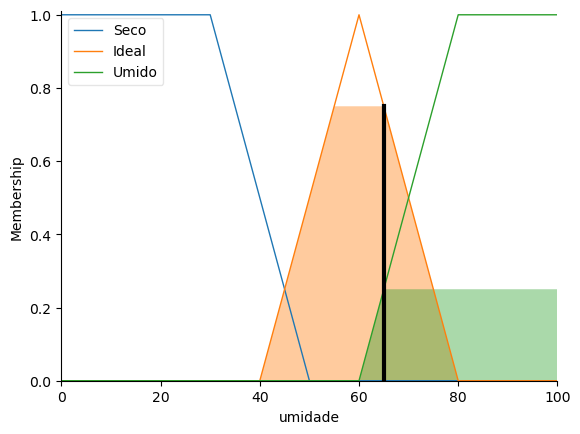

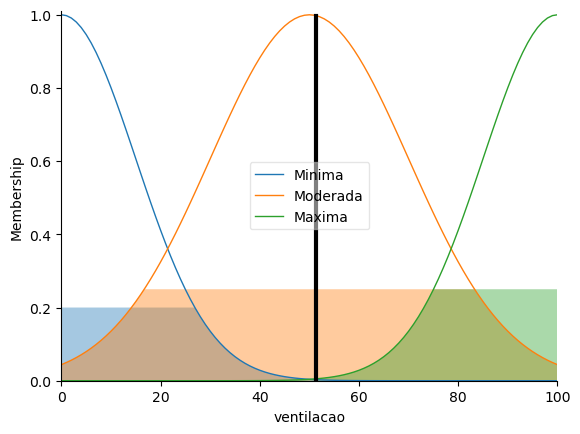

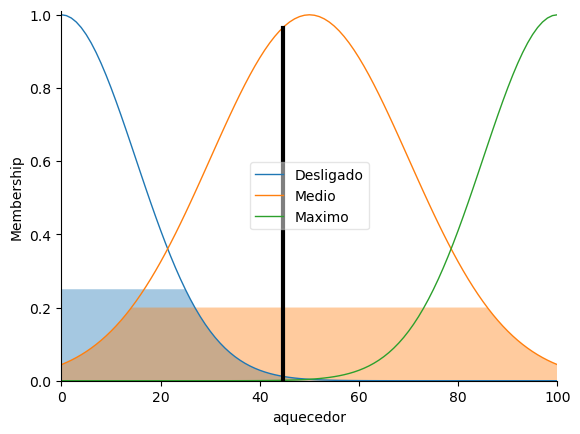

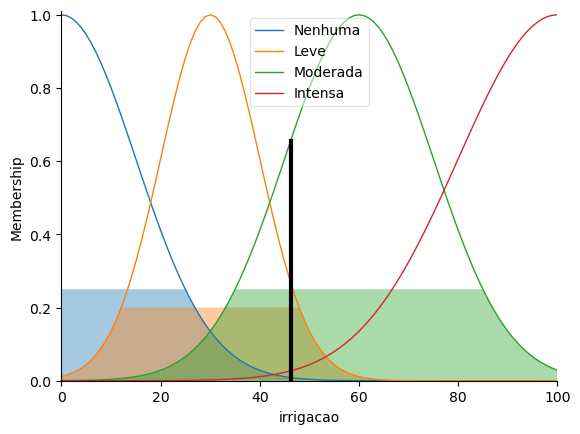

In [21]:
# Visualização
for var in [temperatura, umidade, ventilacao, aquecedor, irrigacao]:
    var.view(sim=simulador)
plt.show()

# Exercícios resolvidos

A célula abaixo organiza o sistema fuzzy da estufa em funções reutilizáveis, testa vários cenários de temperatura e umidade e gera gráficos para comparar as respostas do aquecedor, da ventilação e da irrigação.

Resultados dos cenários testados:
Cenário                    Temp.   Umid.    Aquec.    Vent.   Irrig.
--------------------------------------------------------------------
Muito frio e seco           8.0°C   25.0%     88.0%    12.0%    30.0%
Frio com umidade ideal     15.0°C   65.0%     48.0%    35.5%    27.9%
Condição ideal             22.0°C   60.0%     12.0%    50.0%    59.8%
Quente e seco              30.0°C   35.0%     14.3%    57.8%    49.3%
Muito quente e úmido       35.0°C   85.0%     12.0%    88.0%    12.0%


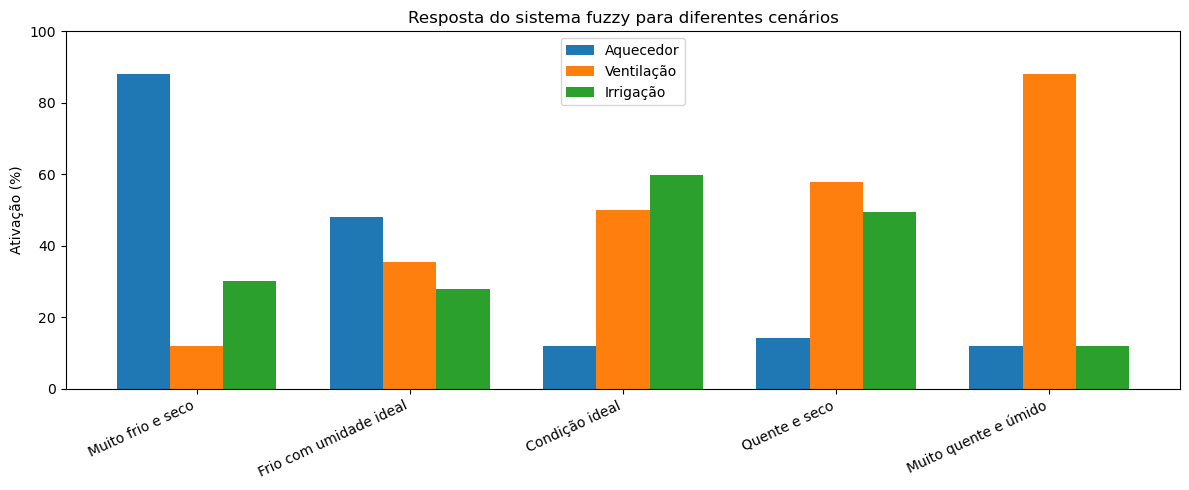


Condição escolhida:
- Temperatura: 28°C
- Umidade: 45%
- Aquecedor: 16.7%
- Ventilação: 50.0%
- Irrigação: 77.8%


In [23]:
# Exercício 1: corrigir a simulação e encapsular em uma função reutilizável
def simular_estufa(temperatura_input, umidade_input):
    simulador_local = ctrl.ControlSystemSimulation(sistema_estufa)
    simulador_local.input['temperatura'] = temperatura_input
    simulador_local.input['umidade'] = umidade_input
    simulador_local.compute()

    return {
        'temperatura': temperatura_input,
        'umidade': umidade_input,
        'aquecedor': simulador_local.output['aquecedor'],
        'ventilacao': simulador_local.output['ventilacao'],
        'irrigacao': simulador_local.output['irrigacao'],
    }


# Exercício 2: testar o controlador com diferentes cenários
cenarios = [
    ('Muito frio e seco', 8, 25),
    ('Frio com umidade ideal', 15, 65),
    ('Condição ideal', 22, 60),
    ('Quente e seco', 30, 35),
    ('Muito quente e úmido', 35, 85),
]

resultados = []
for nome, temperatura_input, umidade_input in cenarios:
    resultado = simular_estufa(temperatura_input, umidade_input)
    resultado['cenario'] = nome
    resultados.append(resultado)

print('Resultados dos cenários testados:')
print(f"{'Cenário':<24} {'Temp.':>7} {'Umid.':>7} {'Aquec.':>9} {'Vent.':>8} {'Irrig.':>8}")
print('-' * 68)
for r in resultados:
    print(
        f"{r['cenario']:<24} {r['temperatura']:>6.1f}°C {r['umidade']:>6.1f}% "
        f"{r['aquecedor']:>8.1f}% {r['ventilacao']:>7.1f}% {r['irrigacao']:>7.1f}%"
    )


# Exercício 3: comparar graficamente as saídas para os cenários simulados
nomes_cenarios = [r['cenario'] for r in resultados]
x = np.arange(len(nomes_cenarios))
largura = 0.25

plt.figure(figsize=(12, 5))
plt.bar(x - largura, [r['aquecedor'] for r in resultados], largura, label='Aquecedor')
plt.bar(x, [r['ventilacao'] for r in resultados], largura, label='Ventilação')
plt.bar(x + largura, [r['irrigacao'] for r in resultados], largura, label='Irrigação')
plt.xticks(x, nomes_cenarios, rotation=25, ha='right')
plt.ylabel('Ativação (%)')
plt.title('Resposta do sistema fuzzy para diferentes cenários')
plt.ylim(0, 100)
plt.legend()
plt.tight_layout()
plt.show()


# Exercício 4: simular uma condição escolhida pelo usuário do notebook
temperatura_input = 28
umidade_input = 45
resultado_usuario = simular_estufa(temperatura_input, umidade_input)

print('\nCondição escolhida:')
print(f"- Temperatura: {resultado_usuario['temperatura']}°C")
print(f"- Umidade: {resultado_usuario['umidade']}%")
print(f"- Aquecedor: {resultado_usuario['aquecedor']:.1f}%")
print(f"- Ventilação: {resultado_usuario['ventilacao']:.1f}%")
print(f"- Irrigação: {resultado_usuario['irrigacao']:.1f}%")